<a href="https://colab.research.google.com/github/sophni/AI_Medical_Internship/blob/main/V4_DeepLesion_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Etape 1 - Montage du DRive et vérification des chemins

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_paths = [
    '/content/drive/MyDrive/Stage2026-Vietnam/Images_png_01/Images_png',
    '/content/drive/MyDrive/Stage2026-Vietnam/Images_png_02/Images_png',
]
csv_path = '/content/drive/MyDrive/Stage2026-Vietnam/DL_info.csv'

for bp in base_paths:
    if os.path.exists(bp):
        print(f"✅ Trouvé : {bp} ({len(os.listdir(bp))} éléments)")
    else:
        print(f"❌ Introuvable : {bp}")

print(f"CSV trouvé : {os.path.exists(csv_path)}")

✅ Trouvé : /content/drive/MyDrive/Stage2026-Vietnam/Images_png_01/Images_png (351 éléments)
✅ Trouvé : /content/drive/MyDrive/Stage2026-Vietnam/Images_png_02/Images_png (373 éléments)
CSV trouvé : True


Etape 2: Focntions utilitaires (chargement image + résolution de chemin)

In [ ]:
import numpy as np
from PIL import Image

def load_deeplesion_image(path):
    """Charge une image PNG DeepLesion et corrige l'offset de +32768."""
    img = Image.open(path)
    img_array = np.array(img).astype(np.int32) - 32768
    return img_array

def csv_filename_to_real_path(file_name, base_paths):
    """
    Convertit '000001_01_01_103.png' -> cherche dans chaque base_path
    et retourne le premier chemin qui existe (ou None si absent partout).
    """
    parts = file_name.replace('.png', '').split('_')
    subfolder = '_'.join(parts[:3])
    slice_name = parts[3] + '.png'

    for bp in base_paths:
        candidate = os.path.join(bp, subfolder, slice_name)
        if os.path.exists(candidate):
            return candidate
    return None

Etape 3 chargmemnt du CSV et association aux images disponibles

In [ ]:
import pandas as pd

df = pd.read_csv(csv_path)
df['real_path'] = df['File_name'].apply(lambda f: csv_filename_to_real_path(f, base_paths))
df['exists'] = df['real_path'].notna()

df_available = df[df['exists']].reset_index(drop=True)

print(f"Total lignes CSV : {len(df)}")
print(f"Lignes avec image disponible : {len(df_available)}")


Total lignes CSV : 32735
Lignes avec image disponible : 1395


In [ ]:
MIN_SAMPLES = 10

df_classif = df_available[df_available['Coarse_lesion_type'] != -1].reset_index(drop=True)

class_counts = df_classif['Coarse_lesion_type'].value_counts()
valid_classes = sorted(class_counts[class_counts >= MIN_SAMPLES].index.tolist())

df_classif_filtered = df_classif[df_classif['Coarse_lesion_type'].isin(valid_classes)].reset_index(drop=True)

print(f"Après retrait de -1 : {len(df_classif)}")
print(f"Classes conservées (>= {MIN_SAMPLES} exemples) : {valid_classes}")
print(f"Nombre de lignes après filtrage : {len(df_classif_filtered)}")
print(df_classif_filtered['Coarse_lesion_type'].value_counts().sort_index())

Après retrait de -1 : 364
Classes conservées (>= 10 exemples) : [2, 3, 4, 5, 6, 7, 8]
Nombre de lignes après filtrage : 360
Coarse_lesion_type
2    100
3     44
4     42
5     50
6     62
7     24
8     38
Name: count, dtype: int64


Étape 4 — Filtrage des classes

In [ ]:
MIN_SAMPLES = 10

df_classif = df_available[df_available['Coarse_lesion_type'] != -1].reset_index(drop=True)

class_counts = df_classif['Coarse_lesion_type'].value_counts()
valid_classes = sorted(class_counts[class_counts >= MIN_SAMPLES].index.tolist())

df_classif_filtered = df_classif[df_classif['Coarse_lesion_type'].isin(valid_classes)].reset_index(drop=True)

print(f"Après retrait de -1 : {len(df_classif)}")
print(f"Classes conservées (>= {MIN_SAMPLES} exemples) : {valid_classes}")
print(f"Nombre de lignes après filtrage : {len(df_classif_filtered)}")
print(df_classif_filtered['Coarse_lesion_type'].value_counts().sort_index())

Après retrait de -1 : 364
Classes conservées (>= 10 exemples) : [2, 3, 4, 5, 6, 7, 8]
Nombre de lignes après filtrage : 360
Coarse_lesion_type
2    100
3     44
4     42
5     50
6     62
7     24
8     38
Name: count, dtype: int64


Etape 5 Split par patient (correction de la fuite de données)

In [ ]:
patient_lesion_counts = df_classif_filtered['Patient_index'].value_counts()

print(f"Nombre de patients uniques : {df_classif_filtered['Patient_index'].nunique()}")
print(f"Nombre total de lésions : {len(df_classif_filtered)}")
print(f"Patients avec plusieurs lésions : {(patient_lesion_counts > 1).sum()}")

Nombre de patients uniques : 52
Nombre total de lésions : 360
Patients avec plusieurs lésions : 50


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

X = df_classif_filtered.reset_index(drop=True)
y = X['Coarse_lesion_type']
groups = X['Patient_index']

# 1ère découpe : ~70% train / ~30% temp (val+test), sans mélanger les patients
sgkf_outer = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
train_idx, temp_idx = next(sgkf_outer.split(X, y, groups))

train_df = X.iloc[train_idx].reset_index(drop=True)
temp_df = X.iloc[temp_idx].reset_index(drop=True)

# 2ème découpe : temp -> val / test (50/50), toujours sans mélanger les patients
sgkf_inner = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
val_idx, test_idx = next(sgkf_inner.split(temp_df, temp_df['Coarse_lesion_type'], temp_df['Patient_index']))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"Train : {len(train_df)} lésions | {train_df['Patient_index'].nunique()} patients")
print(f"Val   : {len(val_df)} lésions | {val_df['Patient_index'].nunique()} patients")
print(f"Test  : {len(test_df)} lésions | {test_df['Patient_index'].nunique()} patients")

Train : 260 lésions | 36 patients
Val   : 64 lésions | 10 patients
Test  : 36 lésions | 6 patients


In [ ]:
train_patients = set(train_df['Patient_index'])
val_patients = set(val_df['Patient_index'])
test_patients = set(test_df['Patient_index'])

print("Fuite train/val  :", len(train_patients & val_patients))
print("Fuite train/test :", len(train_patients & test_patients))
print("Fuite val/test   :", len(val_patients & test_patients))

print("\nRépartition des classes par split :")
print("Train :\n", train_df['Coarse_lesion_type'].value_counts().sort_index())
print("\nVal :\n", val_df['Coarse_lesion_type'].value_counts().sort_index())
print("\nTest :\n", test_df['Coarse_lesion_type'].value_counts().sort_index())

Fuite train/val  : 0
Fuite train/test : 0
Fuite val/test   : 0

Répartition des classes par split :
Train :
 Coarse_lesion_type
2    78
3    39
4    32
5    19
6    53
7     8
8    31
Name: count, dtype: int64

Val :
 Coarse_lesion_type
2     9
3     5
4     7
5    22
6     5
7    15
8     1
Name: count, dtype: int64

Test :
 Coarse_lesion_type
2    13
4     3
5     9
6     4
7     1
8     6
Name: count, dtype: int64


Etape 6 Mapping des classes -> index PyTorch

In [ ]:
class_to_idx = {c: i for i, c in enumerate(valid_classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
num_classes = len(valid_classes)

print("Mapping classe -> index :", class_to_idx)
print("Nombre de classes final :", num_classes)

Mapping classe -> index : {2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6}
Nombre de classes final : 7


Etape 7 — Fonction de recadrage (crop) — reprise du V5 qui fonctionnait bien

In [ ]:
def crop_around_bbox(img_array, bbox, margin=2.5, min_size=40):
    """
    Découpe une zone carrée centrée sur la bbox, avec une marge.
    """
    h_img, w_img = img_array.shape
    x1, y1, x2, y2 = bbox
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    w, h = x2 - x1, y2 - y1

    size = max(w, h) * margin
    size = max(size, min_size)
    half = size / 2

    left = int(max(0, cx - half))
    right = int(min(w_img, cx + half))
    top = int(max(0, cy - half))
    bottom = int(min(h_img, cy + half))

    crop = img_array[top:bottom, left:right]
    if crop.size == 0:
        return img_array
    return crop

Etape 8 Dataset Pytorhc ( avce crop intégré)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class DeepLesionDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, target_size=256, use_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.target_size = target_size
        self.use_crop = use_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_array = load_deeplesion_image(row['real_path'])

        if self.use_crop:
            bbox = [float(x) for x in row['Bounding_boxes'].split(',')]
            img_array = crop_around_bbox(img_array, bbox)

        img_tensor = torch.from_numpy(img_array.copy()).float().unsqueeze(0) / 1000
        img_tensor = F.interpolate(
            img_tensor.unsqueeze(0),
            size=(self.target_size, self.target_size),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

        label = self.class_to_idx[row['Coarse_lesion_type']]
        return img_tensor, label

Etape 9 : DataLoaders

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler

# Création des datasets
train_dataset = DeepLesionDataset(
    train_df,
    class_to_idx,
    target_size=256,
    use_crop=True
)

val_dataset = DeepLesionDataset(
    val_df,
    class_to_idx,
    target_size=256,
    use_crop=True
)

test_dataset = DeepLesionDataset(
    test_df,
    class_to_idx,
    target_size=256,
    use_crop=True
)


# -----------------------------
# Weighted sampling pour équilibrer le train
# -----------------------------

labels_train = [
    class_to_idx[c]
    for c in train_df['Coarse_lesion_type']
]

class_sample_count = np.bincount(labels_train)

# éviter division par zéro
class_sample_count = np.maximum(class_sample_count, 1)

weights = 1.0 / class_sample_count

sample_weights = [
    weights[label]
    for label in labels_train
]


sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


# -----------------------------
# DataLoaders
# -----------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)


print(f"Batches train : {len(train_loader)}")
print(f"Batches val   : {len(val_loader)}")
print(f"Batches test  : {len(test_loader)}")

Batches train : 17
Batches val   : 4
Batches test  : 3


Etape 10 - Poids de classes

In [ ]:
import numpy as np

class_counts_train = train_df['Coarse_lesion_type'].value_counts().sort_index()
counts_ordered = np.array([class_counts_train.get(c, 0) for c in valid_classes])

class_weights = 1.0 / counts_ordered
class_weights = class_weights / class_weights.sum() * num_classes
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Poids par classe :", dict(zip(valid_classes, class_weights)))

Poids par classe : {2: np.float64(0.30067966098735954), 3: np.float64(0.6013593219747191), 4: np.float64(0.7329066736566889), 5: np.float64(1.2343691345796866), 6: np.float64(0.442509689754982), 7: np.float64(2.9316266946267557), 8: np.float64(0.7565488244198079)}


Etape 11 : Device (verifié le GPU) + def du modele | Resnet18

In [ ]:
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device utilisé :", device)

def build_model(num_classes):
    model = models.resnet18(weights='IMAGENET1K_V1')
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

model = build_model(num_classes)
print(f"Modèle prêt avec {num_classes} classes")

Device utilisé : cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Modèle prêt avec 7 classes


Etape 12 : Boucle d'entrainement

In [ ]:
import torch.optim as optim
import copy

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4)

NUM_EPOCHS = 30
PATIENCE = 6

best_val_loss = float('inf')
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train loss: {avg_train_loss:.4f} "
          f"| Val loss: {avg_val_loss:.4f} | Val acc: {val_acc:.2%}")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping : pas d'amélioration depuis {PATIENCE} epochs.")
        break

model.load_state_dict(best_model_state)
print(f"\n📍 Meilleur epoch : {best_epoch} (val loss = {best_val_loss:.4f}) — modèle rechargé")

Epoch 1/30 | Train loss: 0.9650 | Val loss: 1.7661 | Val acc: 25.00%
Epoch 2/30 | Train loss: 0.3936 | Val loss: 1.5225 | Val acc: 32.81%
Epoch 3/30 | Train loss: 0.1942 | Val loss: 1.2561 | Val acc: 68.75%
Epoch 4/30 | Train loss: 0.1408 | Val loss: 1.3859 | Val acc: 71.88%
Epoch 5/30 | Train loss: 0.0783 | Val loss: 1.6345 | Val acc: 67.19%
Epoch 6/30 | Train loss: 0.0970 | Val loss: 1.7463 | Val acc: 71.88%
Epoch 7/30 | Train loss: 0.0566 | Val loss: 1.6222 | Val acc: 65.62%
Epoch 8/30 | Train loss: 0.0321 | Val loss: 1.9362 | Val acc: 64.06%
Epoch 9/30 | Train loss: 0.0621 | Val loss: 1.9588 | Val acc: 64.06%

Early stopping : pas d'amélioration depuis 6 epochs.

📍 Meilleur epoch : 3 (val loss = 1.2561) — modèle rechargé


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, labels=list(range(num_classes)), target_names=[str(idx_to_class[i]) for i in range(num_classes)]))

              precision    recall  f1-score   support

           2       1.00      0.46      0.63        13
           3       0.00      0.00      0.00         0
           4       0.60      1.00      0.75         3
           5       1.00      1.00      1.00         9
           6       0.38      0.75      0.50         4
           7       0.00      0.00      0.00         1
           8       0.25      0.17      0.20         6

    accuracy                           0.61        36
   macro avg       0.46      0.48      0.44        36
weighted avg       0.74      0.61      0.63        36



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix
import torch.optim as optim

X = df_classif_filtered.reset_index(drop=True)
y = X['Coarse_lesion_type']
groups = X['Patient_index']

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

all_y_true, all_y_pred = [], []

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
    print(f"\n===== Fold {fold+1}/5 =====")

    train_df_fold = X.iloc[train_idx].reset_index(drop=True)
    test_df_fold = X.iloc[test_idx].reset_index(drop=True)

    # Vérification de non-fuite (sécurité)
    assert len(set(train_df_fold['Patient_index']) & set(test_df_fold['Patient_index'])) == 0

    classes_fold = sorted(train_df_fold['Coarse_lesion_type'].unique())
    class_to_idx_fold = {c: i for i, c in enumerate(classes_fold)}
    num_classes_fold = len(classes_fold)

    train_ds = DeepLesionDataset(train_df_fold, class_to_idx_fold, target_size=256, use_crop=True)
    test_ds = DeepLesionDataset(test_df_fold, class_to_idx_fold, target_size=256, use_crop=True)
    train_loader_fold = DataLoader(train_ds, batch_size=16, shuffle=True)
    test_loader_fold = DataLoader(test_ds, batch_size=16, shuffle=False)

    class_counts_fold = train_df_fold['Coarse_lesion_type'].value_counts().sort_index()
    counts_ordered_fold = np.array([class_counts_fold.get(c, 0) for c in classes_fold])
    weights_fold = 1.0 / counts_ordered_fold
    weights_fold = weights_fold / weights_fold.sum() * num_classes_fold
    weights_tensor_fold = torch.tensor(weights_fold, dtype=torch.float32).to(device)

    model_fold = build_model(num_classes_fold)
    criterion_fold = nn.CrossEntropyLoss(weight=weights_tensor_fold)
    optimizer_fold = optim.Adam(model_fold.parameters(), lr=1e-4)

    for epoch in range(15):
        model_fold.train()
        for images, labels in train_loader_fold:
            images, labels = images.to(device), labels.to(device)
            optimizer_fold.zero_grad()
            outputs = model_fold(images)
            loss = criterion_fold(outputs, labels)
            loss.backward()
            optimizer_fold.step()
        if (epoch+1) % 5 == 0:
            print(f"  epoch {epoch+1}/15 terminée")

    model_fold.eval()
    with torch.no_grad():
        for images, labels in test_loader_fold:
            images = images.to(device)
            outputs = model_fold(images)
            preds = outputs.argmax(dim=1)
            all_y_true.extend([classes_fold[l] for l in labels.numpy()])
            all_y_pred.extend([classes_fold[p] for p in preds.cpu().numpy()])

    print(f"Fold {fold+1} terminé — {len(test_idx)} lésions testées")


===== Fold 1/5 =====
  epoch 5/15 terminée
  epoch 10/15 terminée
  epoch 15/15 terminée
Fold 1 terminé — 56 lésions testées

===== Fold 2/5 =====
  epoch 5/15 terminée
  epoch 10/15 terminée
  epoch 15/15 terminée
Fold 2 terminé — 60 lésions testées

===== Fold 3/5 =====
  epoch 5/15 terminée
  epoch 10/15 terminée
  epoch 15/15 terminée
Fold 3 terminé — 55 lésions testées

===== Fold 4/5 =====
  epoch 5/15 terminée
  epoch 10/15 terminée
  epoch 15/15 terminée
Fold 4 terminé — 89 lésions testées

===== Fold 5/5 =====
  epoch 5/15 terminée
  epoch 10/15 terminée
  epoch 15/15 terminée
Fold 5 terminé — 100 lésions testées


In [ ]:
all_classes_sorted = sorted(df_classif_filtered['Coarse_lesion_type'].unique())
print(classification_report(all_y_true, all_y_pred, target_names=[str(c) for c in all_classes_sorted]))

              precision    recall  f1-score   support

           2       0.68      0.63      0.65       100
           3       0.80      0.80      0.80        44
           4       0.77      0.86      0.81        42
           5       0.88      0.88      0.88        50
           6       0.62      0.79      0.70        62
           7       0.10      0.12      0.11        24
           8       0.12      0.05      0.07        38

    accuracy                           0.64       360
   macro avg       0.57      0.59      0.57       360
weighted avg       0.62      0.64      0.63       360



Etape 13 - Baseline classique ( Random Forest sur features simples)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report as clf_report_sklearn

def extract_simple_features(img_array):
    """Features basiques : statistiques d'intensité + texture grossière."""
    flat = img_array.flatten()
    features = [
        np.mean(flat), np.std(flat), np.median(flat),
        np.percentile(flat, 25), np.percentile(flat, 75),
        np.min(flat), np.max(flat),
    ]
    # Histogramme grossier (8 bins) comme proxy de texture
    hist, _ = np.histogram(flat, bins=8, range=(-1000, 1000))
    features.extend((hist / hist.sum()).tolist())
    return features

def build_feature_dataset(df, use_crop=True):
    X, y = [], []
    for _, row in df.iterrows():
        img = load_deeplesion_image(row['real_path'])
        if use_crop:
            bbox = [float(v) for v in row['Bounding_boxes'].split(',')]
            img = crop_around_bbox(img, bbox)
        X.append(extract_simple_features(img))
        y.append(row['Coarse_lesion_type'])
    return np.array(X), np.array(y)

print("Extraction des features (train)...")
X_train_rf, y_train_rf = build_feature_dataset(train_df)
print("Extraction des features (test)...")
X_test_rf, y_test_rf = build_feature_dataset(test_df)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

y_pred_rf = rf_model.predict(X_test_rf)
print("\n=== Baseline Random Forest ===")
print(clf_report_sklearn(y_test_rf, y_pred_rf, zero_division=0))

Extraction des features (train)...
Extraction des features (test)...

=== Baseline Random Forest ===
              precision    recall  f1-score   support

           2       0.48      0.77      0.59        13
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         9
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         1
           8       0.50      0.17      0.25         6

    accuracy                           0.56        36
   macro avg       0.28      0.28      0.26        36
weighted avg       0.51      0.56      0.50        36



Etape 14 - CNN from scratch

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 256->128
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 128->64
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 64->32
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_model = SimpleCNN(num_classes).to(device)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

best_cnn_val_loss = float('inf')
best_cnn_state = None
epochs_no_improve = 0

for epoch in range(30):
    cnn_model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        cnn_optimizer.zero_grad()
        loss = cnn_criterion(cnn_model(images), labels)
        loss.backward()
        cnn_optimizer.step()

    cnn_model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn_model(images)
            val_loss += cnn_criterion(outputs, labels).item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/30 | Val loss: {avg_val_loss:.4f} | Val acc: {correct/total:.2%}")

    if avg_val_loss < best_cnn_val_loss:
        best_cnn_val_loss = avg_val_loss
        best_cnn_state = copy.deepcopy(cnn_model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= 6:
        print("Early stopping.")
        break

cnn_model.load_state_dict(best_cnn_state)

cnn_model.eval()
y_true_cnn, y_pred_cnn = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = cnn_model(images).argmax(dim=1)
        y_true_cnn.extend(labels.numpy())
        y_pred_cnn.extend(preds.cpu().numpy())

print("\n=== CNN from scratch ===")
print(classification_report(
    y_true_cnn, y_pred_cnn,
    labels=list(range(num_classes)),
    target_names=[str(idx_to_class[i]) for i in range(num_classes)],
    zero_division=0
))

Epoch 1/30 | Val loss: 1.4727 | Val acc: 37.50%
Epoch 2/30 | Val loss: 1.3873 | Val acc: 39.06%
Epoch 3/30 | Val loss: 1.2287 | Val acc: 45.31%
Epoch 4/30 | Val loss: 1.0173 | Val acc: 51.56%
Epoch 5/30 | Val loss: 1.2479 | Val acc: 54.69%
Epoch 6/30 | Val loss: 1.2859 | Val acc: 56.25%
Epoch 7/30 | Val loss: 2.3602 | Val acc: 56.25%
Epoch 8/30 | Val loss: 0.8459 | Val acc: 56.25%
Epoch 9/30 | Val loss: 1.9945 | Val acc: 62.50%
Epoch 10/30 | Val loss: 1.4253 | Val acc: 54.69%
Epoch 11/30 | Val loss: 1.6806 | Val acc: 60.94%
Epoch 12/30 | Val loss: 1.1142 | Val acc: 57.81%
Epoch 13/30 | Val loss: 1.5262 | Val acc: 57.81%
Epoch 14/30 | Val loss: 1.6853 | Val acc: 60.94%
Early stopping.

=== CNN from scratch ===
              precision    recall  f1-score   support

           2       0.00      0.00      0.00        13
           3       0.00      0.00      0.00         0
           4       0.16      1.00      0.27         3
           5       1.00      1.00      1.00         9
          

Etape 15 - Métriques cliniques ( ROC-AUC, sensibilité/spécificité)

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Récupérer les probabilités du modèle ResNet18 (V6) sur le test set
model.eval()
y_true_proba, y_proba = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        y_true_proba.extend(labels.numpy())
        y_proba.extend(probs.cpu().numpy())

y_true_proba = np.array(y_true_proba)
y_proba = np.array(y_proba)

# Binarisation pour le calcul one-vs-rest
y_true_bin = label_binarize(y_true_proba, classes=list(range(num_classes)))

print("=== Sensibilité (rappel) / Spécificité par classe ===")
cm = confusion_matrix(y_true_proba, y_proba.argmax(axis=1), labels=list(range(num_classes)))
for i, c in enumerate(valid_classes):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    print(f"Classe {c} : sensibilité = {sensitivity:.2f} | spécificité = {specificity:.2f}")

print("\n=== ROC-AUC par classe (one-vs-rest) ===")
auc_scores = []
for i, c in enumerate(valid_classes):
    if y_true_bin[:, i].sum() == 0:
        print(f"Classe {c} : AUC non calculable (absente du test set)")
        continue
    auc = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
    auc_scores.append(auc)
    print(f"Classe {c} : AUC = {auc:.3f}")

print(f"\nAUC macro-moyenne : {np.mean(auc_scores):.3f}")

=== Sensibilité (rappel) / Spécificité par classe ===
Classe 2 : sensibilité = 0.46 | spécificité = 1.00
Classe 3 : sensibilité = nan | spécificité = 0.94
Classe 4 : sensibilité = 1.00 | spécificité = 0.94
Classe 5 : sensibilité = 1.00 | spécificité = 1.00
Classe 6 : sensibilité = 0.75 | spécificité = 0.84
Classe 7 : sensibilité = 0.00 | spécificité = 0.94
Classe 8 : sensibilité = 0.17 | spécificité = 0.90

=== ROC-AUC par classe (one-vs-rest) ===
Classe 2 : AUC = 0.846
Classe 3 : AUC non calculable (absente du test set)
Classe 4 : AUC = 0.980
Classe 5 : AUC = 1.000
Classe 6 : AUC = 0.930
Classe 7 : AUC = 0.429
Classe 8 : AUC = 0.744

AUC macro-moyenne : 0.821


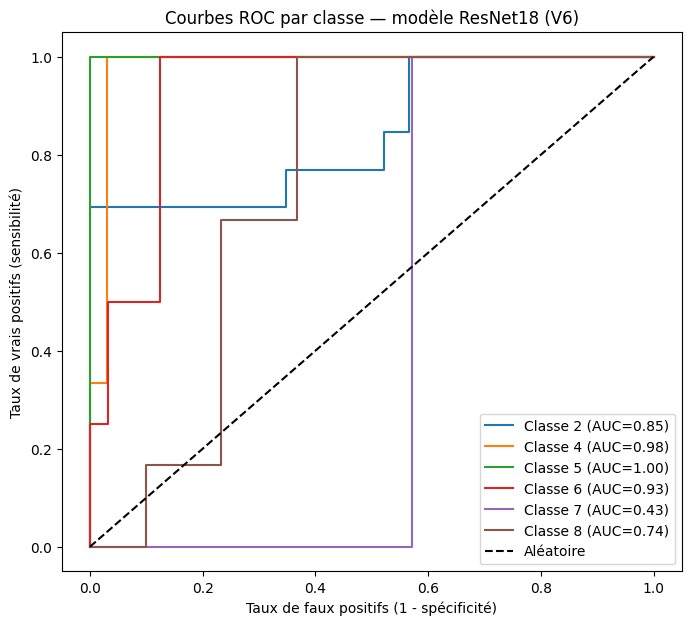

In [ ]:
plt.figure(figsize=(8, 7))
for i, c in enumerate(valid_classes):
    if y_true_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f"Classe {c} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire")
plt.xlabel("Taux de faux positifs (1 - spécificité)")
plt.ylabel("Taux de vrais positifs (sensibilité)")
plt.title("Courbes ROC par classe — modèle ResNet18 (V6)")
plt.legend()
plt.show()

In [ ]:
# AUC macro-moyenne excluant les classes trop peu représentées (< 3 exemples positifs)
reliable_aucs = []
for i, c in enumerate(valid_classes):
    n_positive = y_true_bin[:, i].sum()
    if n_positive < 3:
        print(f"Classe {c} exclue du calcul (seulement {n_positive} exemple(s) positif(s))")
        continue
    auc = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
    reliable_aucs.append(auc)

print(f"\nAUC macro-moyenne (classes fiables uniquement) : {np.mean(reliable_aucs):.3f}")

Classe 3 exclue du calcul (seulement 0 exemple(s) positif(s))
Classe 7 exclue du calcul (seulement 1 exemple(s) positif(s))

AUC macro-moyenne (classes fiables uniquement) : 0.900
